## 多臂老虎机问题
1. 假设有一个拥有$k$根拉杠的老虎机, 每根拉杆都对应一个关于奖励的概率分布$R_i, i\in[1, k]$.
2. 可以每次拉动一根拉杆, 并从对应的奖励概率分布中获取一个奖励$r$
3. 目标: 操作$T$次拉杠后获得尽可能高的累积奖励

Q: 应该采用什么样的策略, 才能使获得的累积奖励最高？

NOTE: trade-off between exploration and expliation.

比如: 探店 vs 去老店. 如果有对环境的完整信息, 那么就不需要去exploration. 问题时, 我们通常无法获得完整信息, 所以需要再探索和利用间做trade-off.

多臂老虎机问题与强化学习的主要区别: 多臂老虎机问题里的action不会改变enviroment, 可以看作是stateless reinforcement learning.


epsilon-贪婪算法的累积懊悔为： 6.179677699524186
epsilon-贪婪算法的累积懊悔为： 438.27409981348643
epsilon-贪婪算法的累积懊悔为： 272.25920124248023
epsilon-贪婪算法的累积懊悔为： 490.75269403255425
epsilon-贪婪算法的累积懊悔为： 875.9606567954785


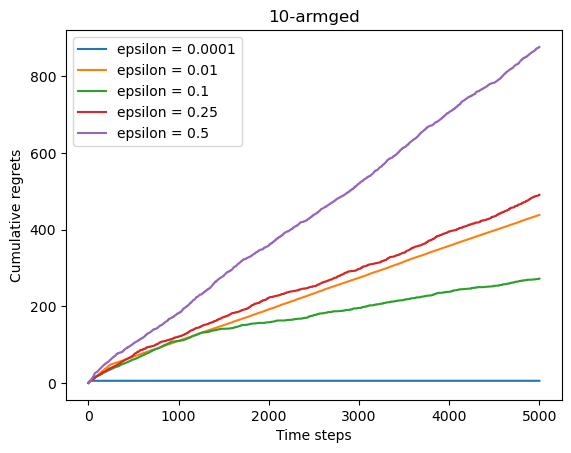

In [14]:
%matplotlib inline  

import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

# 每个拉杆的奖励分布
class BernoulliBandit:
    
    __slots__ = ["probs", "best_prob", "best_idx", "K"]

    def __init__(self, K):
        # 拉动每根拉杆的获奖概率: 如果获奖, 奖励为1; 如果没有获奖, 奖励为0
        # TODO: 可以有多种概率分布实现
        self.probs = np.random.uniform(size=K)
        self.best_idx = np.argmax(self.probs)
        self.best_prob = self.probs[self.best_idx]
        self.K = K

    def step(self, k):
        return 1 if np.random.rand() < self.probs[k] else 0

    
class Solver(ABC):

    __slots__ = ["bandit", "counts", "regret", "regrets", "actions"]

    def __init__(self, bandit):
        self.bandit = bandit
        self.counts = np.zeros(self.bandit.K)
        # regret: 最优拉杠的期望奖励 - 拉动当前拉杆的期望奖励
        # 多臂啦户籍问题的目标为最大化累积奖励, 等价于最小化累积regret
        self.regret = 0             # 累积regret
        self.actions = []
        self.regrets = []           # 每一步的累积regret

    def update_regret(self, k):
        # TODO: if not bernoulli bandit, the expected reword is not self.bandit.best_prob
        self.regret += (self.bandit.best_prob - self.bandit.probs[k])
        self.regrets.append(self.regret)

    @abstractmethod
    def run_one_step(self):
        """返回当前动作选择哪一根拉杆, 由具体策略实现"""
        pass
        # 策略模式
        # raise NotImplementdError

    def run(self, num_steps):
        for _ in range(num_steps):
            # print(f"self.regret = {self.bandit.probs}")
            k = self.run_one_step()
            self.counts[k] += 1
            self.actions.append(k)
            self.update_regret(k)


class EpsilonGreedySolver(Solver):

    __slots__ = ["epsilon", "estimates"]
    # __slots__ = Parent.__slots__ + ["epsilon", "estimates"]       # since Python3.9

    def __init__(self, bandit, epsilon=0.01, init_prob=1.0):
        # 由于有super().__init__(bandit), 会合并父类__slots__
        super().__init__(bandit)
        # epsilon的概率去探索; 1 - epsilon的概率去利用
        self.epsilon = epsilon
        # 所有拉杠的初始期望奖励的估计值
        self.estimates = np.array([init_prob] * self.bandit.K)

    def run_one_step(self):
        if np.random.random() < self.epsilon:
            # exploration
            k = np.random.randint(0, self.bandit.K)
        else:
            # exploitation
            k = np.argmax(self.estimates)
        
        reward = self.bandit.step(k)
        #更新期望奖励估计
        self.estimates[k] = (reward + self.counts[k] * self.estimates[k]) / (self.counts[k] + 1)
        return k


def plot_results(solvers, solver_names):
    for idx, solver in enumerate(solvers):
        time_list = range(len(solver.regrets))
        plt.plot(time_list, solver.regrets, label=solver_names[idx])

    plt.xlabel("Time steps")
    plt.ylabel("Cumulative regrets")
    plt.title(f"{solvers[0].bandit.K}-armged")
    plt.legend()
    plt.show()



np.random.seed(66)
K = 10
bandit_10_arm = BernoulliBandit(K)

epsilons = [0.0001, 0.01, 0.1, 0.25, 0.5]
# epsilons = [0.001]
epsilon_greedy_solver_list = [EpsilonGreedySolver(bandit_10_arm, epsilon=e) for e in epsilons]
solver_name_list = [f"epsilon = {eps}" for eps in epsilons]
for epsilon_greedy_solver in epsilon_greedy_solver_list:
    epsilon_greedy_solver.run(5000)
    print('epsilon-贪婪算法的累积懊悔为：', epsilon_greedy_solver.regret)
plot_results(epsilon_greedy_solver_list, solver_name_list)

## UCB: Upper Confidence Bound 上置信界算法
如果某个拉杆被拉了更多的次数, 那么它的探索程度更高. 如果某个拉杆被拉了较少的次数, 那么它的探索程度较低.

对探索程度高的拉杆, 我们对它的分布有更大的把握, 因而可以更准确地估计出它的奖励均值. 对探索程度低的拉杆, 我们对其分布的把握不够, 因而需要更多的探索.

> Deterministic policy: UCB1

- Initialization: Play each machine once
- Loop:
  - Play machine $j$ that maximizes $\overline{x}_j + \sqrt{\frac{2\ln n}{n_j}}$

$\overline{x}_j$: 第$j$台机器的期望reward [经验均值]

$n_j$: 第$j$台机器被拉动的次数 [探索项, 未充分探索的拉杆这一项会比较大]

注释:
- 平方根项表示**不确定性度量**
- UCB算法每次选择拉杆前, 先估计每根拉杆的期望奖励的上界（只有一个非常小的概率$p$超过这个上界）


### 霍夫丁不等式(Hoeffding's Inequality)
假设有$n$个独立同分布的随机变量$X_1$ ... $X_n$, 它们的取值范围均为$[0, 1]$, 则对任意$u > 0$有如下不等式:

$$\mathbb{P} [ \mathbb{E}[X] > \overline{X} + u] \leq e^{-2nu^2}$$

上置信界算法的累积懊悔为： 85.13002822630952


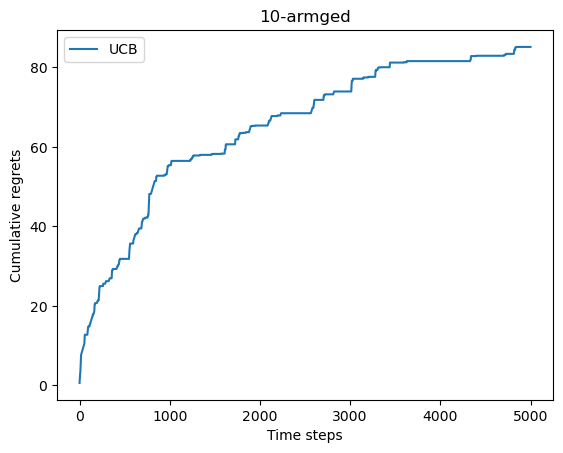

In [16]:
class UCB1(Solver):
    def __init__(self, bandit, coef, init_proba=1.0):
        super(UCB1, self).__init__(bandit)
        self.coef = coef
        self.trial_num = 0
        self.estimates = [init_proba] * self.bandit.K

    def run_one_step(self):
        self.trial_num += 1
        ucb = self.estimates + self.coef * np.sqrt(
            np.log(self.trial_num) / (2 * (self.counts + 1))
        )
        # 选择上置信界最大的拉杆
        k = np.argmax(ucb)

        reward = self.bandit.step(k)
        # self.estimates[k] += 1.0 / (self.counts[k] + 1) * (reward - self.estimates[k])
        self.estimates[k] = (reward + self.counts[k] * self.estimates[k]) / (self.counts[k] + 1)

        return k

np.random.seed(66)
coef = 1  # 控制不确定性比重的系数
UCB_solver = UCB1(bandit_10_arm, coef)
UCB_solver.run(5000)
print('上置信界算法的累积懊悔为：', UCB_solver.regret)
plot_results([UCB_solver], ["UCB"])